# 01 · Op Fusion and Arithmetic Intensity

**Goal:** run the attention QKV projection (tokens × model weights) on a GPU and optimise it to better use the hardware, by fusing three matmuls into one. We measure how fusion changes *arithmetic intensity* (FLOPs per byte moved) and achieved FLOP/s on FP16 tensor cores as the number of tokens grows.

**Requirements:** NVIDIA GPU with tensor cores (compute capability ≥ 7.0) + CUDA + PyTorch. The notebook is GPU-agnostic: set your GPU's spec-sheet numbers in section 1 and everything else adapts.
On a machine without CUDA (e.g. a laptop) the code still runs for correctness, but performance numbers are meaningless and GPU-only cells are skipped.

## 0. Hardware

What GPU are we running on? We only need three facts: its **name**, its **compute capability** (the architecture generation, which decides what the tensor cores support), and its **DRAM** (VRAM) size.

In [1]:
import torch

GIGA = 1e9
TERA = 1e12

IS_CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if IS_CUDA_AVAILABLE else "cpu")

if IS_CUDA_AVAILABLE:
    properties = torch.cuda.get_device_properties(DEVICE)
    print(f"GPU                : {properties.name}")
    print(f"Compute capability : {properties.major}.{properties.minor} (SM{properties.major}{properties.minor})")
    print(f"DRAM               : {properties.total_memory / GIGA:.1f} GB")
else:
    print("No CUDA GPU found: running on CPU for correctness only.")

GPU                : Tesla T4
Compute capability : 7.5 (SM75)
DRAM               : 15.6 GB


## 1. Spec Sheet

PyTorch can't tell us peak throughput, so we take it from the GPU's datasheet. Defaults below are the **NVIDIA T4** (Turing, SM75).

| T4 datasheet | Value |
|---|---|
| Peak FP16 tensor core | 65 TFLOP/s |
| Peak INT8 tensor core | 130 TOP/s |
| Peak INT4 tensor core | 260 TOP/s |
| Peak FP32 (no tensor cores) | 8.1 TFLOP/s |
| Memory bandwidth | 320 GB/s (GDDR6) |

SM75 tensor cores natively support **FP16, INT8 and INT4**. We use **FP16**: it's the floating-point format the tensor cores run natively, so our matmuls can reach the 65 TFLOP/s peak.

✏️ On a different GPU, replace these values with its datasheet numbers and pick a precision its tensor cores support.

In [2]:
PEAK_TENSOR_CORE_FLOPS_PER_SECOND = 65 * TERA
PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND = 320 * GIGA
DTYPE = torch.float16

## 2. The Operation

A model represents each token (a word or word-piece) as a list of `d` numbers, called its **hidden state**. `d` is the **hidden size**; we use `d = 768` (GPT-2 small).

Attention needs three versions of every token, a **query**, a **key** and a **value**, each obtained by multiplying the token's hidden state by a fixed weight matrix of the model. Stacking `N` tokens as rows of a matrix `X`:

```
X          : [N, d]      N tokens, d numbers each
Wq, Wk, Wv : [d, d]      model weights
Q = X @ Wq,   K = X @ Wk,   V = X @ Wv      each [N, d]
```

In PyTorch `@` is **matrix multiplication** (`torch.matmul`), not element-wise `*`.

### Where the cost comes from

DRAM (the GPU's memory) and the compute units are separate, connected by a memory bus. On a T4 that bus moves 320 GB/s. Every matrix multiplication must bring its inputs across the bus to compute, and send its result back to DRAM. The math is fast; the travel is often what limits speed. Fusing is about doing the same math with less travel.

In [3]:
HIDDEN_SIZE = 768
TOKEN_COUNT = 128
RANDOM_SEED = 0

torch.manual_seed(RANDOM_SEED)
X = torch.randn(TOKEN_COUNT, HIDDEN_SIZE, device=DEVICE, dtype=DTYPE)
W_q = torch.randn(HIDDEN_SIZE, HIDDEN_SIZE, device=DEVICE, dtype=DTYPE) / HIDDEN_SIZE ** 0.5
W_k = torch.randn(HIDDEN_SIZE, HIDDEN_SIZE, device=DEVICE, dtype=DTYPE) / HIDDEN_SIZE ** 0.5
W_v = torch.randn(HIDDEN_SIZE, HIDDEN_SIZE, device=DEVICE, dtype=DTYPE) / HIDDEN_SIZE ** 0.5

print(f"X: {tuple(X.shape)} | Wq, Wk, Wv: {tuple(W_q.shape)} each | dtype: {DTYPE}")

X: (128, 768) | Wq, Wk, Wv: (768, 768) each | dtype: torch.float16


Weights are divided by `√d` (standard initialisation) so the FP16 outputs stay in a sensible range.

## 3. Unfused: Q, K, V Computed Separately

Three separate multiplications. Each one is a round trip over the bus: inputs travel DRAM → compute, the result travels compute → DRAM.

| Multiplication | Travels to compute | Travels back to DRAM |
|---|---|---|
| `X @ Wq` | `X`, `Wq` | `Q` |
| `X @ Wk` | `X`, `Wk` | `K` |
| `X @ Wv` | `X`, `Wv` | `V` |

3 round trips = **6 travels**, and `X` crosses the bus **3 times** even though it's the same data every time.

In [4]:
Q_unfused = X @ W_q
K_unfused = X @ W_k
V_unfused = X @ W_v

print(f"Q, K, V: {tuple(Q_unfused.shape)} each")

Q, K, V: (128, 768) each


## 4. Fused: One Multiplication

Place the three weights side by side into one `[d, 3d]` matrix. A single multiplication then produces `Q`, `K` and `V` together as one `[N, 3d]` result: its first `d` columns are `Q`, the next `d` are `K`, the last `d` are `V`.

```
W_qkv = [Wq | Wk | Wv]        [d, 3d]   built once, when the model is loaded
QKV   = X @ W_qkv             [N, 3d]
```

| Multiplication | Travels to compute | Travels back to DRAM |
|---|---|---|
| `X @ W_qkv` | `X`, `W_qkv` | `QKV` |

1 round trip = **2 travels**. `X` crosses the bus **once**.

Note what *didn't* shrink: `W_qkv` is the same bytes as `Wq + Wk + Wv`, and `QKV` the same bytes as `Q + K + V`. The saving is exactly the two extra trips of `X`. How much that matters depends on how big `X` is relative to the weights; the next section measures it.

In [5]:
W_qkv = torch.cat([W_q, W_k, W_v], dim=1)

QKV = X @ W_qkv
Q_fused, K_fused, V_fused = QKV.split(HIDDEN_SIZE, dim=1)

print(f"W_qkv: {tuple(W_qkv.shape)} | QKV: {tuple(QKV.shape)}")

W_qkv: (768, 2304) | QKV: (128, 2304)


Check that fusing didn't change the result. Tiny FP16 differences are allowed since the multiplications may add terms in a different order.

In [6]:
FP16_TOLERANCE = 1e-2

torch.testing.assert_close(Q_fused, Q_unfused, atol=FP16_TOLERANCE, rtol=FP16_TOLERANCE)
torch.testing.assert_close(K_fused, K_unfused, atol=FP16_TOLERANCE, rtol=FP16_TOLERANCE)
torch.testing.assert_close(V_fused, V_unfused, atol=FP16_TOLERANCE, rtol=FP16_TOLERANCE)
print("Fused and unfused Q, K, V match ✓")

Fused and unfused Q, K, V match ✓


## 5. Counting FLOPs and Bytes

Both are fixed by the shapes, so we calculate them rather than measure them.

**FLOPs.** Each output number is a dot product of length `d`: `d` multiplies + `d` adds = `2d` FLOPs.

| | Output numbers | FLOPs |
|---|---|---|
| One `X @ W` | `N·d` | `2·N·d²` |
| Unfused (3 matmuls) | `3·N·d` | `6·N·d²` |
| Fused (`X @ W_qkv`) | `3·N·d` | `6·N·d²` |

Fusing does **not** change the FLOPs.

**Bytes.** Every travel over the bus moves the tensor's bytes (FP16 = 2 bytes per number).

| | `X` | Weights | Outputs |
|---|---|---|---|
| Unfused | 3 × `N·d` | 3 × `d·d` | 3 × `N·d` |
| Fused | 1 × `N·d` | 3 × `d·d` | 3 × `N·d` |

**Arithmetic intensity** = FLOPs ÷ bytes: how much work we do per byte moved. Same FLOPs with fewer bytes means higher intensity.

In [7]:
BYTES_PER_ELEMENT = X.element_size()

flops_unfused = 3 * 2 * TOKEN_COUNT * HIDDEN_SIZE * HIDDEN_SIZE
flops_fused = 2 * TOKEN_COUNT * HIDDEN_SIZE * (3 * HIDDEN_SIZE)

bytes_unfused = (3 * X.numel() + W_q.numel() + W_k.numel() + W_v.numel()
                 + Q_unfused.numel() + K_unfused.numel() + V_unfused.numel()) * BYTES_PER_ELEMENT
bytes_fused = (X.numel() + W_qkv.numel() + QKV.numel()) * BYTES_PER_ELEMENT

intensity_unfused = flops_unfused / bytes_unfused
intensity_fused = flops_fused / bytes_fused

print(f"N = {TOKEN_COUNT}, d = {HIDDEN_SIZE}, {BYTES_PER_ELEMENT} bytes per element\n")
print(f"{'':8} {'MFLOPs':>8} {'MB moved':>9} {'FLOP/byte':>10}")
print(f"{'Unfused':8} {flops_unfused / 1e6:8.1f} {bytes_unfused / 1e6:9.2f} {intensity_unfused:10.1f}")
print(f"{'Fused':8} {flops_fused / 1e6:8.1f} {bytes_fused / 1e6:9.2f} {intensity_fused:10.1f}")

N = 128, d = 768, 2 bytes per element

           MFLOPs  MB moved  FLOP/byte
Unfused     453.0      4.72       96.0
Fused       453.0      4.33      104.7


### Ridge point

The GPU can do `PEAK_TENSOR_CORE_FLOPS_PER_SECOND` of work but only move `PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND` over the bus. Dividing the two gives the **ridge point**: the intensity at which compute and bus are equally busy.

- Intensity **below** the ridge: the tensor cores wait on the bus (**memory-bound**). Achievable FLOP/s = intensity × bandwidth.
- Intensity **above** the ridge: the bus keeps up (**compute-bound**). Achievable FLOP/s = peak.

This ceiling, `min(peak, intensity × bandwidth)`, is the **roofline**.

In [8]:
RIDGE_POINT = PEAK_TENSOR_CORE_FLOPS_PER_SECOND / PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND

roofline_unfused = min(PEAK_TENSOR_CORE_FLOPS_PER_SECOND, intensity_unfused * PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND)
roofline_fused = min(PEAK_TENSOR_CORE_FLOPS_PER_SECOND, intensity_fused * PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND)

print(f"Ridge point: {RIDGE_POINT:.0f} FLOP/byte\n")
print(f"Unfused: {intensity_unfused:6.1f} FLOP/byte -> at most {roofline_unfused / TERA:5.1f} TFLOP/s")
print(f"Fused  : {intensity_fused:6.1f} FLOP/byte -> at most {roofline_fused / TERA:5.1f} TFLOP/s")

Ridge point: 203 FLOP/byte

Unfused:   96.0 FLOP/byte -> at most  30.7 TFLOP/s
Fused  :  104.7 FLOP/byte -> at most  33.5 TFLOP/s


### How intensity changes with the number of tokens

Weights are fixed at `3·d·d` numbers; `X` and the outputs grow with `N`. With few tokens the weights dominate the bytes and both versions are memory-bound. As `N` grows, the repeated reads of `X` become a bigger share of the bytes, so fusing helps more.

Working the formulas through (the `2·` for bytes-per-element cancels against the `2·` in FLOPs):

- Unfused intensity = `N·d / (2N + d)`, levels off at `d/2`
- Fused intensity = `3·N·d / (4N + 3d)`, levels off at `3d/4`

    N  unfused    fused   gain
    1      1.0      1.0  1.00x
    2      2.0      2.0  1.00x
    4      4.0      4.0  1.00x
    8      7.8      7.9  1.01x
   16     15.4     15.6  1.01x
   32     29.5     30.3  1.03x
   64     54.9     57.6  1.05x
  128     96.0    104.7  1.09x
  256    153.6    177.2  1.15x
  512    219.4    271.1  1.24x
 1024    279.3    368.6  1.32x
 2048    323.4    449.6  1.39x
 4096    351.1    505.0  1.44x


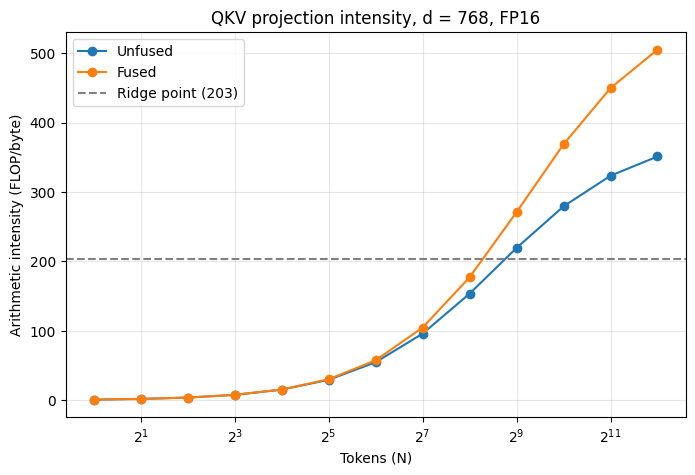

In [9]:
import matplotlib.pyplot as plt

TOKEN_COUNT_SWEEP = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

intensity_sweep_unfused = []
intensity_sweep_fused = []
for token_count in TOKEN_COUNT_SWEEP:
    sweep_flops = 6 * token_count * HIDDEN_SIZE * HIDDEN_SIZE
    sweep_bytes_unfused = (3 * token_count * HIDDEN_SIZE + 3 * HIDDEN_SIZE * HIDDEN_SIZE + 3 * token_count * HIDDEN_SIZE) * BYTES_PER_ELEMENT
    sweep_bytes_fused = (token_count * HIDDEN_SIZE + 3 * HIDDEN_SIZE * HIDDEN_SIZE + 3 * token_count * HIDDEN_SIZE) * BYTES_PER_ELEMENT
    intensity_sweep_unfused.append(sweep_flops / sweep_bytes_unfused)
    intensity_sweep_fused.append(sweep_flops / sweep_bytes_fused)

print(f"{'N':>5} {'unfused':>8} {'fused':>8} {'gain':>6}")
for token_count, unfused, fused in zip(TOKEN_COUNT_SWEEP, intensity_sweep_unfused, intensity_sweep_fused):
    print(f"{token_count:5d} {unfused:8.1f} {fused:8.1f} {fused / unfused:5.2f}x")

plt.figure(figsize=(8, 5))
plt.plot(TOKEN_COUNT_SWEEP, intensity_sweep_unfused, "o-", label="Unfused")
plt.plot(TOKEN_COUNT_SWEEP, intensity_sweep_fused, "o-", label="Fused")
plt.axhline(RIDGE_POINT, color="gray", linestyle="--", label=f"Ridge point ({RIDGE_POINT:.0f})")
plt.xscale("log", base=2)
plt.xlabel("Tokens (N)")
plt.ylabel("Arithmetic intensity (FLOP/byte)")
plt.title(f"QKV projection intensity, d = {HIDDEN_SIZE}, FP16")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Reading the plot**

- At small `N` both lines overlap: the weights are nearly all the bytes, so saving two reads of a tiny `X` barely matters.
- As `N` grows, fused pulls ahead and crosses the ridge earlier (around `N ≈ 313` vs `N ≈ 431` on a T4). Between those two points, fusing turns a memory-bound operation into a compute-bound one.
- At large `N` the gain approaches `(3d/4) / (d/2) = 1.5x`.

These are ceilings on paper. The next section times both versions on the GPU to see how close the real hardware gets.

## 6. Measuring on the GPU

Now we time both versions for every `N` in the sweep and turn the times into achieved FLOP/s.

How the timing works:
- **Warmup:** the first few calls pay one-time costs (cuBLAS picking an algorithm, memory allocation), so they're run and thrown away.
- **Loop:** one call at small `N` takes microseconds, too short to time reliably. We run it many times and divide.
- **CUDA events:** GPU calls return immediately and run in the background. Events are timestamps recorded *on the GPU*, and `synchronize()` waits until the work is really done before reading them.

Achieved FLOP/s = FLOPs ÷ time per call. Achieved bandwidth = bytes ÷ time per call.

On CPU the loop runs with fewer iterations just to check the code; the numbers are not meaningful.

In [10]:
import time

WARMUP_ITERATIONS = 10
TIMING_ITERATIONS = 100 if IS_CUDA_AVAILABLE else 3
MILLISECONDS_PER_SECOND = 1e3

PROJECTIONS = {
    "Unfused": lambda tokens: (tokens @ W_q, tokens @ W_k, tokens @ W_v),
    "Fused": lambda tokens: tokens @ W_qkv,
}

seconds_per_call = {name: [] for name in PROJECTIONS}

for token_count in TOKEN_COUNT_SWEEP:
    tokens = torch.randn(token_count, HIDDEN_SIZE, device=DEVICE, dtype=DTYPE)
    for name, projection in PROJECTIONS.items():
        for _ in range(WARMUP_ITERATIONS):
            projection(tokens)

        if IS_CUDA_AVAILABLE:
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            torch.cuda.synchronize()
            start_event.record()
            for _ in range(TIMING_ITERATIONS):
                projection(tokens)
            end_event.record()
            torch.cuda.synchronize()
            elapsed_seconds = start_event.elapsed_time(end_event) / MILLISECONDS_PER_SECOND
        else:
            start_time = time.perf_counter()
            for _ in range(TIMING_ITERATIONS):
                projection(tokens)
            elapsed_seconds = time.perf_counter() - start_time

        seconds_per_call[name].append(elapsed_seconds / TIMING_ITERATIONS)

print(f"Timed {len(TOKEN_COUNT_SWEEP)} token counts x {len(PROJECTIONS)} versions, {TIMING_ITERATIONS} iterations each")

Timed 13 token counts x 2 versions, 100 iterations each


In [11]:
MICROSECONDS_PER_SECOND = 1e6

achieved_flops_per_second = {name: [] for name in PROJECTIONS}
achieved_bytes_per_second = {name: [] for name in PROJECTIONS}
intensity_sweep = {"Unfused": intensity_sweep_unfused, "Fused": intensity_sweep_fused}

for name in PROJECTIONS:
    for token_count, intensity, seconds in zip(TOKEN_COUNT_SWEEP, intensity_sweep[name], seconds_per_call[name]):
        sweep_flops = 6 * token_count * HIDDEN_SIZE * HIDDEN_SIZE
        achieved_flops_per_second[name].append(sweep_flops / seconds)
        achieved_bytes_per_second[name].append(sweep_flops / intensity / seconds)

print(f"{'N':>5} | {'unfused us':>10} {'TFLOP/s':>8} {'GB/s':>6} | {'fused us':>9} {'TFLOP/s':>8} {'GB/s':>6} | {'speedup':>7}")
for index, token_count in enumerate(TOKEN_COUNT_SWEEP):
    unfused_seconds = seconds_per_call["Unfused"][index]
    fused_seconds = seconds_per_call["Fused"][index]
    print(f"{token_count:5d} | "
          f"{unfused_seconds * MICROSECONDS_PER_SECOND:10.1f} {achieved_flops_per_second['Unfused'][index] / TERA:8.2f} {achieved_bytes_per_second['Unfused'][index] / GIGA:6.0f} | "
          f"{fused_seconds * MICROSECONDS_PER_SECOND:9.1f} {achieved_flops_per_second['Fused'][index] / TERA:8.2f} {achieved_bytes_per_second['Fused'][index] / GIGA:6.0f} | "
          f"{unfused_seconds / fused_seconds:6.2f}x")

    N | unfused us  TFLOP/s   GB/s |  fused us  TFLOP/s   GB/s | speedup
    1 |       44.5     0.08     80 |      22.2     0.16    159 |   2.00x
    2 |       70.3     0.10     51 |      37.1     0.19     96 |   1.90x
    4 |       51.4     0.28     70 |      37.2     0.38     96 |   1.38x
    8 |       51.9     0.55     70 |      37.6     0.75     96 |   1.38x
   16 |       53.5     1.06     69 |      40.3     1.41     90 |   1.33x
   32 |       64.0     1.77     60 |      39.5     2.86     94 |   1.62x
   64 |       89.3     2.54     46 |      42.8     5.29     92 |   2.09x
  128 |      111.3     4.07     42 |      58.9     7.69     73 |   1.89x
  256 |      145.5     6.23     41 |      68.2    13.29     75 |   2.13x
  512 |      188.4     9.62     44 |     115.2    15.73     58 |   1.64x
 1024 |      339.1    10.69     38 |     227.8    15.91     43 |   1.49x
 2048 |      431.8    16.79     52 |     263.8    27.48     61 |   1.64x
 4096 |      657.4    22.05     63 |     655.8    2

### Achieved FLOP/s and the roofline

Two plots:
- **Left:** achieved TFLOP/s against `N`, with the spec-sheet peak as a dashed line.
- **Right:** the roofline. The x-axis is intensity, the solid line is the ceiling `min(peak, intensity × bandwidth)`, and each dot is a measured run. A dot's distance below the line is performance the hardware could give but we didn't get.

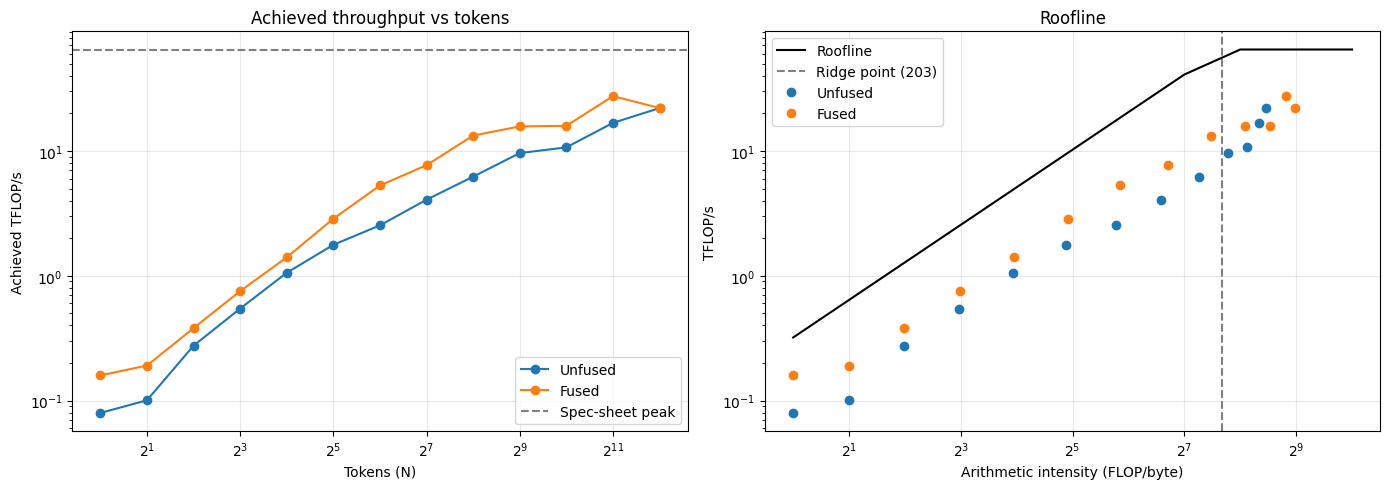

In [12]:
roofline_intensities = [2 ** exponent for exponent in range(0, 11)]
roofline_ceiling = [min(PEAK_TENSOR_CORE_FLOPS_PER_SECOND, intensity * PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND) / TERA
                    for intensity in roofline_intensities]

figure, (throughput_axis, roofline_axis) = plt.subplots(1, 2, figsize=(14, 5))

for name in PROJECTIONS:
    throughput_axis.plot(TOKEN_COUNT_SWEEP, [flops / TERA for flops in achieved_flops_per_second[name]], "o-", label=name)
throughput_axis.axhline(PEAK_TENSOR_CORE_FLOPS_PER_SECOND / TERA, color="gray", linestyle="--", label="Spec-sheet peak")
throughput_axis.set_xscale("log", base=2)
throughput_axis.set_yscale("log")
throughput_axis.set_xlabel("Tokens (N)")
throughput_axis.set_ylabel("Achieved TFLOP/s")
throughput_axis.set_title("Achieved throughput vs tokens")
throughput_axis.legend()
throughput_axis.grid(True, alpha=0.3)

roofline_axis.plot(roofline_intensities, roofline_ceiling, "k-", label="Roofline")
roofline_axis.axvline(RIDGE_POINT, color="gray", linestyle="--", label=f"Ridge point ({RIDGE_POINT:.0f})")
for name in PROJECTIONS:
    roofline_axis.plot(intensity_sweep[name], [flops / TERA for flops in achieved_flops_per_second[name]], "o", label=name)
roofline_axis.set_xscale("log", base=2)
roofline_axis.set_yscale("log")
roofline_axis.set_xlabel("Arithmetic intensity (FLOP/byte)")
roofline_axis.set_ylabel("TFLOP/s")
roofline_axis.set_title("Roofline")
roofline_axis.legend()
roofline_axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What to look for (on the GPU)**

- **Small `N`:** both versions are far below the roofline. Each call is only microseconds, so the fixed cost of launching a GPU call dominates. Unfused launches 3 calls, fused launches 1, so fusing can win here for a reason the intensity math doesn't capture: fewer launches.
- **Middle `N`:** the dots should climb along the slanted (memory-bound) part of the roofline, with fused slightly higher and to the right.
- **Large `N`:** both flatten out below the spec-sheet peak. Real kernels rarely exceed ~60-80% of peak, and the T4 also lowers its clock when it gets hot.
- **Speedup column:** compare it with the intensity gain from section 5. Where speedup is larger than the intensity gain, launch overhead is the reason; where it's close, the saved bytes are.